In [7]:
# logs produced by running e.g. probe_past_tokens.py --token_offset 1 --nums True --num_texts 10000000

num_logs_f = {i: "notebooks/logs/logs_probe_past_numbers_max_10000000_offsets=[%s].tsv" % i for i in range(1, 6)}
tokens_logs_f = {i: "notebooks/logs/logs_probe_past_tokens_offsets=[%s].tsv" % i for i in range(1, 6)}

In [31]:
import pandas as pd

header = ["_1", "offset", "_2", "train_step", "_3", "train_acc", "_4", "val_acc", "_5", "best_layer", "_6", "best_step", "_7", "best_val_acc"]

num_logs_df = pd.concat([pd.read_csv(f, sep="\t", names=header) for f in num_logs_f.values()])
num_logs_df["offset"] = num_logs_df["offset"].apply(lambda x: -int(x))
token_logs_df = pd.concat([pd.read_csv(f, sep="\t", names=header) for f in tokens_logs_f.values()])
token_logs_df["offset"] = token_logs_df["offset"].apply(lambda x: -int(x))

num_logs_df.head()

,_1,offset,_2,train_step,_3,train_acc,_4,val_acc,_5,best_layer,_6,best_step,_7,best_val_acc
0,Offset:,-1,train step:,10,train acc:,0.0,valid acc:,0.001,best layer:,15,from step:,10,best valid acc:,0.002
1,Offset:,-1,train step:,20,train acc:,0.0,valid acc:,0.003,best layer:,16,from step:,20,best valid acc:,0.003
2,Offset:,-1,train step:,30,train acc:,0.0,valid acc:,0.002,best layer:,16,from step:,20,best valid acc:,0.003
3,Offset:,-1,train step:,40,train acc:,0.0,valid acc:,0.000,best layer:,16,from step:,20,best valid acc:,0.003
4,Offset:,-1,train step:,50,train acc:,0.0,valid acc:,0.002,best layer:,16,from step:,20,best valid acc:,0.003


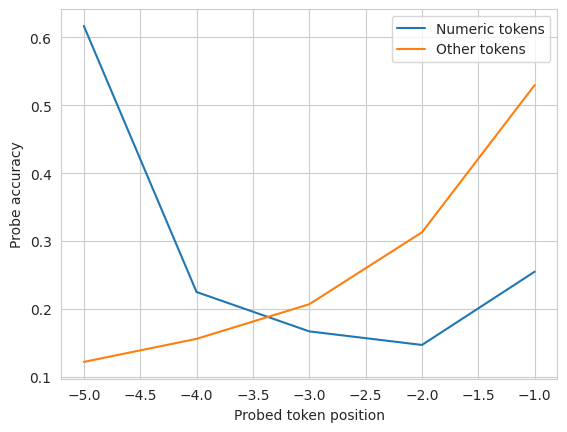

In [40]:
ax = num_logs_df.groupby("offset").max()["best_val_acc"].plot(label="Numeric tokens")
token_logs_df.groupby("offset").max()["best_val_acc"].plot(ax=ax, label="Other tokens")

ax.set_ylabel("Probe accuracy")
ax.set_xlabel("Probed token position")
ax.legend()
